In [41]:
# import useful libraries
import os #fornisce funzioni per interagire con il sistema operativo
import glob #trova file con pattern specifici, tipo cerca tutti i file .jpg
import numpy as np #per il calcolo numerico
import pandas as pd #per manipolare dati tabulari tipo exel
import matplotlib.pyplot as plt #per creare e grafici e visualizzazioni di dati
import scipy.io as sio # useful because ground truth labels are uploaded as .mat files
import cv2 # per cariche e processare le immagini
import matplotlib.patches as patches #per disegnare forme sopra le immagini
import seaborn as sns

In [42]:
%pwd
DATA_PATH = 'data/raw/lizard'
os.listdir(DATA_PATH)

image_paths = glob.glob(os.path.join(DATA_PATH, "lizard_images1", "Lizard_images1", "*.png*")) \
             + glob.glob(os.path.join(DATA_PATH, "lizard_images2", "Lizard_images2", "*.png*"))

mask_paths = glob.glob(os.path.join(DATA_PATH, "overlay", "Overlay", "*.jpg"))

print(len(image_paths))
print(len(mask_paths))

238
238


In [7]:
# Utilitary function to load labels
def load_labels(label_path):
    """Loading the labels within the Lizard dataset."""
    label = sio.loadmat(label_path)

    inst_map  = label['inst_map']   # (H, W) int32 map #mappa delle istanze: ogni pixel
    #contiene l’ID del nucleo a cui appartiene (0 = sfondo).
    nuclei_id = np.squeeze(label['id']) #lista di ID dei nuclei (numeri interi).
    classes   = np.squeeze(label['class']) # classe di ogni nucleo (es. epiteliale,
    #infiammatorio, stromale, ecc.).
    bboxs     = label['bbox'] # bounding box di ciascun nucleo (x_min, y_min, x_max, y_max).
    centroids = label['centroid'] #coordinate (x, y) del centroide di ogni nucleo.

    # Get the unique values in the instance map - each value corresponds to a single nucleus.
    unique_values = np.unique(inst_map).tolist()[1:] # remove 0, che corrisponderebbe allo sfondo

    # Convert nuclei_id to list.
    nuclei_id = np.squeeze(nuclei_id).tolist()
    for value in unique_values:
        # Get the position of the corresponding value
        idx = nuclei_id.index(value)

        class_ = classes[idx]
        bbox = bboxs[idx]

    dict = {
        'inst_map': inst_map,
        'nuclei_id': nuclei_id,
        'classes': classes,
        'bboxs': bboxs,
        'centroids': centroids
    }
    return dict


label = load_labels(os.path.join(DATA_PATH, 'lizard_labels', 'Lizard_Labels', 'Labels', 'consep_1.mat'))

In [9]:
inst_map = label['inst_map']
num_nuclei = len(np.unique(inst_map)) - 1  # tolgo lo 0 (background)

print(f"Numero di nuclei: {num_nuclei}")

num_nuclei = len(label['nuclei_id'])
print(f"Numero di nuclei: {num_nuclei}")

Numero di nuclei: 528
Numero di nuclei: 528


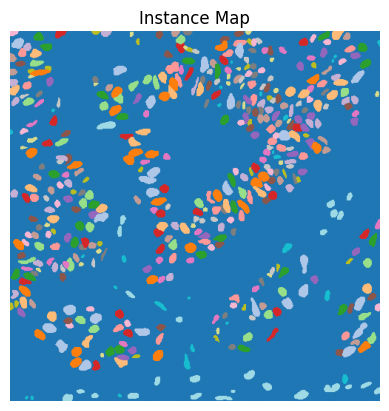

In [10]:
# ESEMPIO INSTANCE MASK, mappa colori categorica
inst_map = label['inst_map'] 
bboxs = label['bboxs']
nuclei_id = label['nuclei_id']
centroids = label['centroids']
classes = label ['classes']
# variabili singole più facili da manipolare

plt.imshow(inst_map, cmap="tab20") 
plt.title("Instance Map") 
plt.axis("off") 
plt.show() 

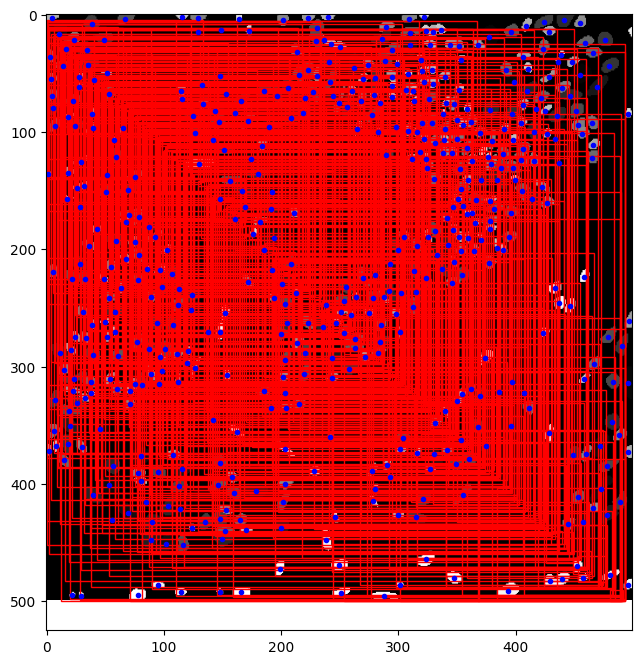

In [11]:
# 2. GRAFICO BOUNDING BOXES E CENTROIDS
fig, ax = plt.subplots(figsize=(8,8)) 
ax.imshow(inst_map, cmap="gray") #Carica la mappa dei nuclei come sfondo (GRIGIO)
for idx, nucleus_id in enumerate(nuclei_id): 
    x1, y1, x2, y2 = bboxs[idx] 
    cx, cy = centroids[idx]  
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height,
                             linewidth=1, edgecolor="r", facecolor="none") 
    # la funzione rect in input riceve rispettivamente (punto di partenza, larghezza (x2-x1) e altezza (y2-y1)) 
    #edgecolor="r": r sta per Red (Rosso). Disegna il contorno.
    #facecolor="none" dice di non colorare l'interno del rettangolo
    ax.add_patch(rect)

    ax.plot(cx, cy, "bo", markersize=3) #bo": Sta per Blue Object ( cerchietto blu). ## densità nuclei

plt.show()



In [12]:
label_paths = glob.glob(os.path.join(DATA_PATH, "lizard_labels", "Lizard_Labels", "Labels", "*.mat"))

label_dict = {
    os.path.basename(p).split('.')[0]: p
    for p in label_paths
}

In [14]:
data_images = []

for img_path in image_paths:
    
    name = os.path.basename(img_path).split('.')[0]
    
    if name not in label_dict:
        continue
    
    label_path = label_dict[name]
    
    # --- IMMAGINE ---
    img = np.array(Image.open(img_path))

    if img.ndim == 3:
        R = img[:,:,0].flatten()[::10]
        G = img[:,:,1].flatten()[::10]
        B = img[:,:,2].flatten()[::10]

        R_mean = np.mean(R)
        G_mean = np.mean(G)
        B_mean = np.mean(B)

        R_std = np.std(R)
        G_std = np.std(G)
        B_std = np.std(B)

    # --- LABEL (.mat) ---
    label = load_labels(label_path)
    inst_map = label['inst_map']

    n_nuclei = len(np.unique(inst_map)) - 1

    area = inst_map.shape[0] * inst_map.shape[1]
    density = n_nuclei / area

    # --- SALVA ---
    data_images.append({
        "image_id": name,
        "nuclei": n_nuclei,
        "density": density,
        "R_mean": R_mean,
        "G_mean": G_mean,
        "B_mean": B_mean,
        "R_std": R_std,
        "G_std": G_std,
        "B_std": B_std
    })

df_images = pd.DataFrame(data_images)
print(df_images.head())

    image_id  nuclei   density      R_mean      G_mean      B_mean      R_std  \
0  consep_12     115  0.000460  228.356120  208.199320  231.890680  26.334785   
1    crag_62    3099  0.001352  211.355794  162.129129  212.603394  27.148400   
2    crag_63    1342  0.000585  237.268615  228.817747  236.591894  16.066420   
3  consep_13     646  0.002584  203.653320  177.348800  224.425240  36.066498   
4  consep_11     566  0.002264  208.615400  185.222840  225.325680  42.137760   

       G_std      B_std  
0  37.455490  19.925923  
1  33.916637  19.397623  
2  23.927826  14.645967  
3  42.345174  22.356005  
4  49.164687  24.690671  


In [15]:
data_nuclei = []

for img_path in image_paths:
    
    name = os.path.basename(img_path).split('.')[0]
    
    if name not in label_dict:
        continue
    
    label_path = label_dict[name]
    label = load_labels(label_path)

    nuclei_ids = label["nuclei_id"]
    bboxs = label["bboxs"]
    centroids = label["centroids"]

    for i, nucleus_id in enumerate(nuclei_ids):
        bbox = bboxs[i]
        centroid = centroids[i]

        data_nuclei.append({
            "image_id": name,
            "nucleus_id": nucleus_id,
            "x_min": bbox[0],
            "y_min": bbox[1],
            "x_max": bbox[2],
            "y_max": bbox[3],
            "centroid_x": centroid[0],
            "centroid_y": centroid[1]
        })

df_nuclei = pd.DataFrame(data_nuclei)
print(df_nuclei.head())

    image_id  nucleus_id  x_min  y_min  x_max  y_max  centroid_x  centroid_y
0  consep_12           1    237    246     22     34   27.061728  241.123457
1  consep_12           2     57     68    310    317  313.033898   62.508475
2  consep_12           3     95    103    244    254  248.733333   98.550000
3  consep_12           4    275    283    290    299  293.851852  278.166667
4  consep_12           5    485    495    265    274  269.423077  489.519231


In [19]:
df_dataset = pd.DataFrame([{
    "num_images": len(df_images),
    "num_labels": len(df_images),
    "mean_nuclei_per_image": df_images["nuclei"].mean(),
    "mean_density": df_images["density"].mean(),
    "R_mean_dataset": df_images["R_mean"].mean(),
    "G_mean_dataset": df_images["G_mean"].mean(),
    "B_mean_dataset": df_images["B_mean"].mean()
}])

print(df_dataset)


   num_images  num_labels  mean_nuclei_per_image  mean_density  \
0         238         238            1814.760504      0.001784   

   R_mean_dataset  G_mean_dataset  B_mean_dataset  
0      194.665272      150.384742      201.032087  


In [20]:
# NUMERI TOTALI NUCLEI E MEDIA NUCLEI PER IMMAGINE

print(f"Nuclei totali nel dataset:", df_images["nuclei"].sum())
print(f"Media di nuclei per immagine: ", df_images["nuclei"].mean() )

Nuclei totali nel dataset: 431913
Media di nuclei per immagine:  1814.7605042016808


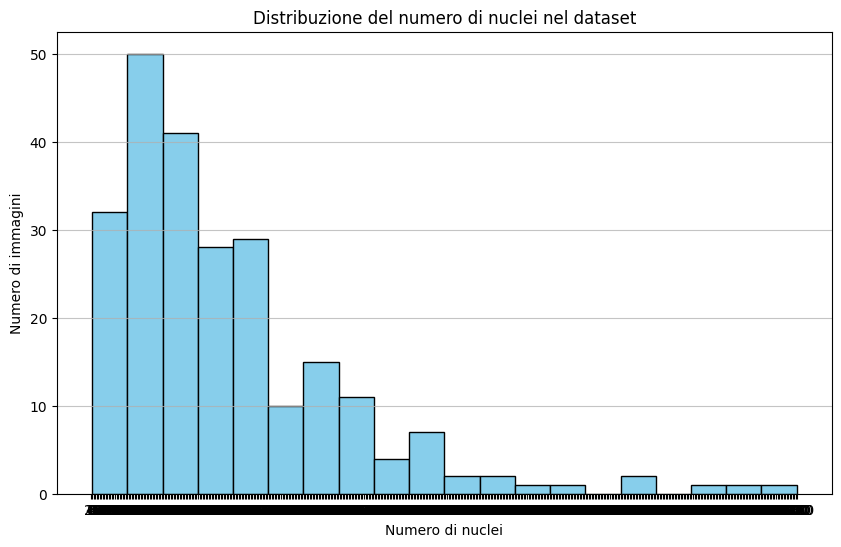

In [21]:
# GRAFICO DISTRIBUZIONE NUCLEI NELLE IMMAGINI

plt.figure(figsize=(10, 6))
plt.hist(df_images["nuclei"], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuzione del numero di nuclei nel dataset')
plt.xlabel('Numero di nuclei')
plt.ylabel('Numero di immagini')
plt.xticks(np.arange(0, df_images["nuclei"].max() + 20, 20))
plt.grid(axis='y', alpha=0.75)
plt.savefig("hist_images_VS_nuclei_Lizard.png", dpi=300)

plt.show() 

In [22]:
# DENSITà MEDIA E DEVIAZIONE STANDARD

print(f"densità media:", df_images["density"].mean())
print(f"deviazione standard: ", df_images["density"].std() )




densità media: 0.0017843468413947905
deviazione standard:  0.0008365128958769413


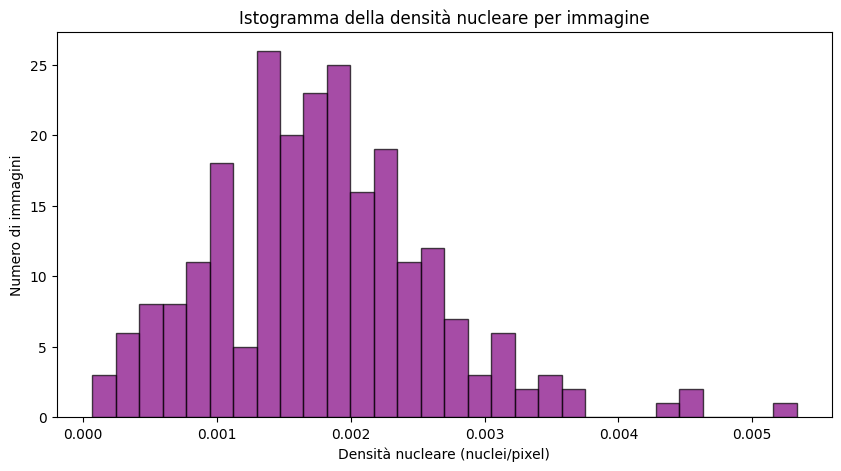

In [23]:
# ISOGRAMMA DENSITà NUCLEARE (NUCLEO/PIXEL)

plt.figure(figsize=(10,5))
plt.hist(df_images["density"], bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title("Istogramma della densità nucleare per immagine")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.savefig("hist_images_VS_density_Lizard.png", dpi=300)

plt.show()

In [32]:
def analyze_labels(label_folder):
    label_paths = glob.glob(os.path.join(label_folder, "*.mat"))
    
    nuclei_counts = []
    densities = []

    for label_path in label_paths:
        label = sio.loadmat(label_path)
        inst_map = label['inst_map']

        num_nuclei = len(np.unique(inst_map)) - 1

        nuclei_counts.append(num_nuclei)

        area = inst_map.shape[0] * inst_map.shape[1]
        densities.append(num_nuclei / area)

    return nuclei_counts, densities

In [33]:
subdatasets = {
    "consep": [],
    "crag": [],
    "dpath": [],
    "glas": [],
    "pannuke": []
}

for img_path in image_paths:
    name = os.path.basename(img_path).split('.')[0].lower()  # tutto in minuscolo
    for ds in subdatasets.keys():
        if name.startswith(ds):
            subdatasets[ds].append(img_path)
            break

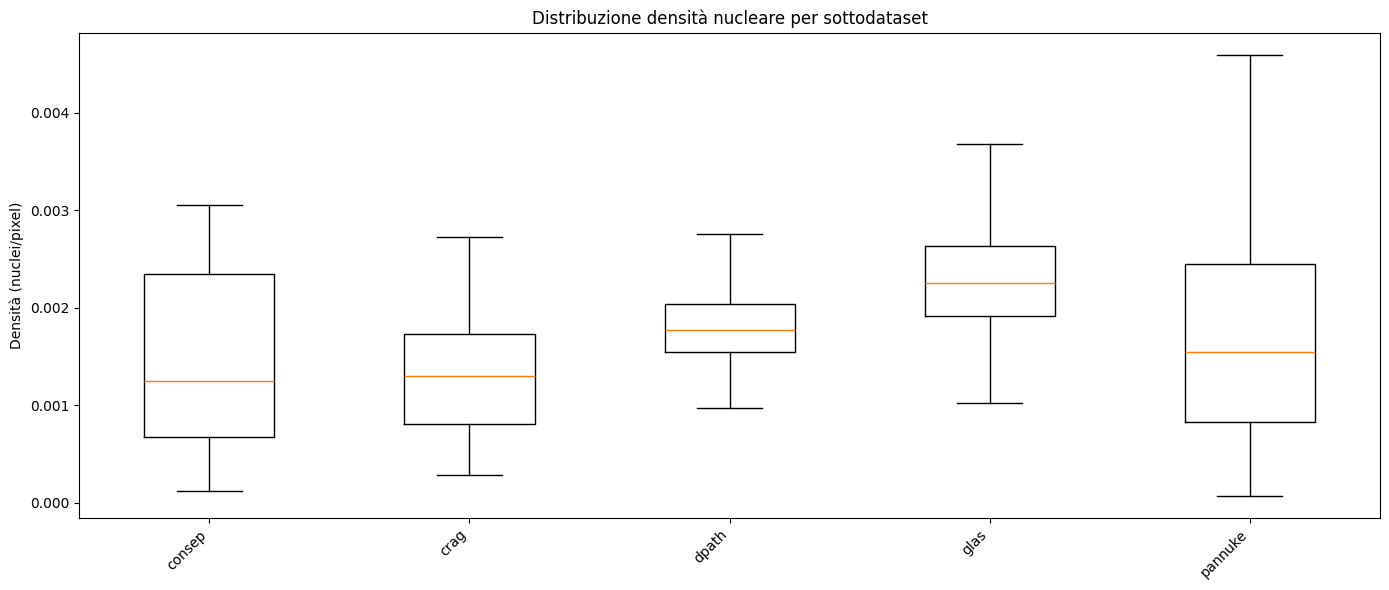

In [35]:
# BOXPLOT DENSITà

import matplotlib.pyplot as plt

# Lista dei sottodataset
subdatasets = ["consep", "crag", "dpath", "glas", "pannuke"]

# Prepara i dati per il boxplot
all_densities = []
labels = []

for ds in subdatasets:
    # Filtra le immagini che iniziano con il prefisso del sottodataset
    densities = df_images[df_images["image_id"].str.lower().str.startswith(ds)]["density"].values
    
    if len(densities) > 0:  # evita sottodataset senza immagini
        all_densities.append(densities)
        labels.append(ds)

# Crea il boxplot
plt.figure(figsize=(14,6))
plt.boxplot(all_densities, tick_labels=labels, showfliers=False)  # <--- usa tick_labels
plt.xticks(rotation=45, ha='right')
plt.title("Distribuzione densità nucleare per sottodataset")
plt.ylabel("Densità (nuclei/pixel)")
plt.tight_layout()
plt.savefig("boxplot_density_per_subdataset.png", dpi=300)
plt.show()

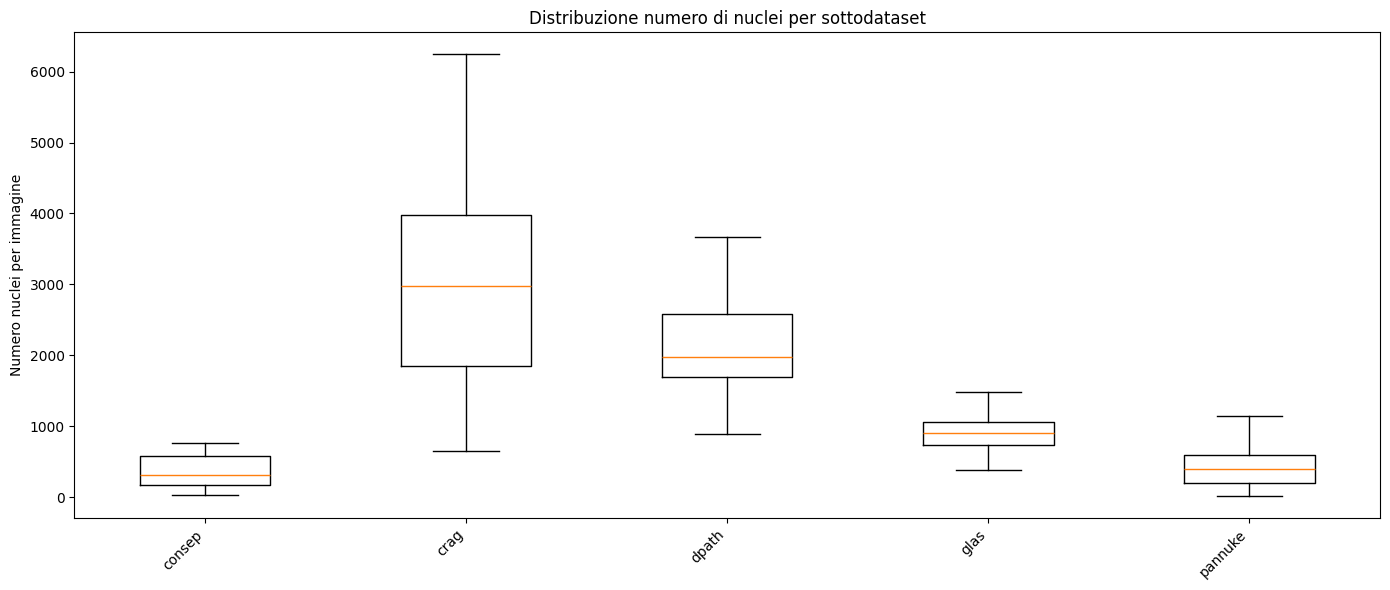

In [36]:
# Lista dei sottodataset
subdatasets = ["consep", "crag", "dpath", "glas", "pannuke"]

# Prepara i dati per il boxplot
all_counts = []
labels = []

for ds in subdatasets:
    counts = df_images[df_images["image_id"].str.lower().str.startswith(ds)]["nuclei"].values
    if len(counts) > 0:
        all_counts.append(counts)
        labels.append(ds)

# Crea il boxplot
plt.figure(figsize=(14,6))
plt.boxplot(all_counts, tick_labels=labels, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title("Distribuzione numero di nuclei per sottodataset")
plt.ylabel("Numero nuclei per immagine")
plt.tight_layout()
plt.savefig("boxplot_nuclei_per_subdataset.png", dpi=300)
plt.show()

In [37]:
# TEST ANOVA
from scipy.stats import f_oneway

# ANOVA
f_stat, p_value = f_oneway(*all_counts)

print("ANOVA results:")
print("F-statistic:", f_stat)
print("p-value:", p_value)

# p< 0.05 almeno un gruppo è significativamente diverso  (noi basso, sottodataset con media diversa)
# HO DIFFERENZE FORTI TRA I TESSUTI
# F-statistic alto: variazione tra i grupi rispetto alla variazione interna a ciascun gruppo


ANOVA results:
F-statistic: 43.79926668416603
p-value: 2.178746099193656e-27


In [39]:
# TEST KRUSKAL-WALLIS
from scipy.stats import kruskal

h_stat, p_value = kruskal(*all_counts)

print("Kruskal-Wallis results:")
print("H-statistic:", h_stat)
print("p-value:", p_value)

Kruskal-Wallis results:
H-statistic: 166.5393493209436
p-value: 5.782439563319327e-35


In [40]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# crea array con tutti i dati e i rispettivi gruppi
counts_all = []
groups_all = []
for ds, counts in zip(labels, all_counts):
    counts_all.extend(counts)
    groups_all.extend([ds]*len(counts))

tukey = pairwise_tukeyhsd(endog=counts_all, groups=groups_all, alpha=0.05)
print(tukey)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
group1  group2  meandiff  p-adj    lower      upper    reject
-------------------------------------------------------------
consep    crag  2577.6719    0.0  1669.6301  3485.7137   True
consep   dpath  2066.0489    0.0  1164.6111  2967.4867   True
consep    glas   531.4816 0.4981  -381.0151  1443.9782  False
consep pannuke     87.375 0.9993  -930.7431  1105.4931  False
  crag   dpath   -511.623 0.0953 -1075.4191    52.1732  False
  crag    glas -2046.1903    0.0 -2627.5045 -1464.8761   True
  crag pannuke -2490.2969    0.0  -3226.395 -1754.1987   True
 dpath    glas -1534.5674    0.0 -2105.5107   -963.624   True
 dpath pannuke -1978.6739    0.0 -2706.6098  -1250.738   True
  glas pannuke  -444.1066 0.4694 -1185.6932   297.4801  False
-------------------------------------------------------------


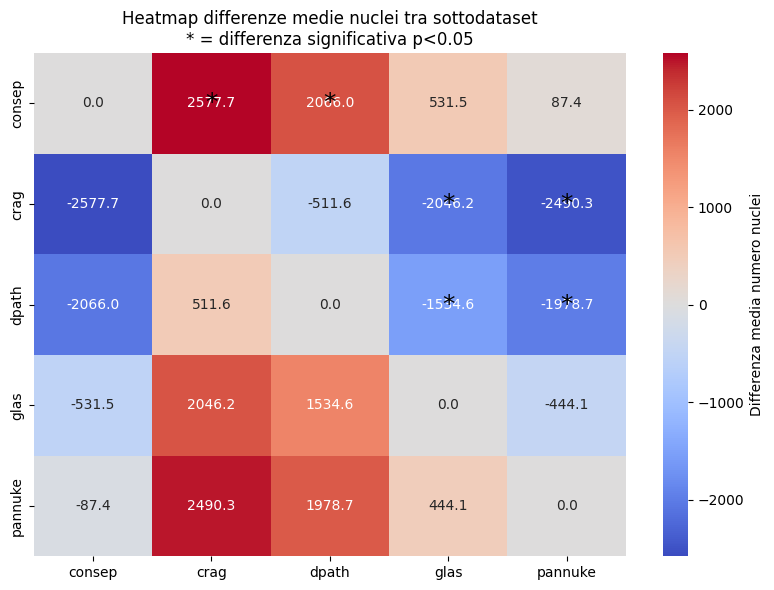

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Risultati Tukey HSD ---
# (gruppo1, gruppo2, differenza media, p-value)
tukey_results = [
    ("consep","crag",2577.6719,0.0),
    ("consep","dpath",2066.0489,0.0),
    ("consep","glas",531.4816,0.4981),
    ("consep","pannuke",87.375,0.9993),
    ("crag","dpath",-511.623,0.0953),
    ("crag","glas",-2046.1903,0.0),
    ("crag","pannuke",-2490.2969,0.0),
    ("dpath","glas",-1534.5674,0.0),
    ("dpath","pannuke",-1978.6739,0.0),
    ("glas","pannuke",-444.1066,0.4694)
]

# --- Sottodataset ---
groups = ["consep","crag","dpath","glas","pannuke"]

# --- Matrice differenze medie ---
diff_matrix = pd.DataFrame(np.zeros((len(groups), len(groups))), index=groups, columns=groups)

# --- Matrice significatività (bool) ---
signif_matrix = pd.DataFrame(False, index=groups, columns=groups, dtype=bool)

for g1, g2, meandiff, p in tukey_results:
    diff_matrix.loc[g1,g2] = meandiff
    diff_matrix.loc[g2,g1] = -meandiff  # simmetrica
    signif_matrix.loc[g1,g2] = signif_matrix.loc[g2,g1] = p < 0.05

# --- Plot Heatmap ---
plt.figure(figsize=(8,6))
sns.heatmap(diff_matrix, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            cbar_kws={'label':'Differenza media numero nuclei'})

# Aggiungi asterischi per significatività
for i, g1 in enumerate(groups):
    for j, g2 in enumerate(groups):
        if i < j and signif_matrix.loc[g1,g2]:  # solo metà superiore
            plt.text(j+0.5, i+0.5, '*', color='black', ha='center', va='center', fontsize=18)

plt.title("Heatmap differenze medie nuclei tra sottodataset\n* = differenza significativa p<0.05")
plt.tight_layout()
plt.show()

In [45]:
# ANALISI RGB


# array vuoti per ogni canale
R_values = []
G_values = []
B_values = []

# loop su tutte le immagini
for img_path in image_paths:
    img = Image.open(img_path)          # apri immagine
    img = np.array(img)                  # conversione in array numpy
    if img.ndim == 3:                    # RGB
        R_values.extend(img[:,:,0].flatten()[::10])
        G_values.extend(img[:,:,1].flatten()[::10])
        B_values.extend(img[:,:,2].flatten()[::10])

# Statistiche RGB

R_mean = np.mean(R_values)
G_mean = np.mean(G_values)
B_mean = np.mean(B_values)

R_std = np.std(R_values)
G_std = np.std(G_values)
B_std = np.std(B_values)

print("📊 STATISTICHE RGB\n")

print("🔴 Red  -> Media:", R_mean, " | Deviazione standard:", R_std)
print("🟢 Green-> Media:", G_mean, " | Deviazione standard:", G_std)
print("🔵 Blue -> Media:", B_mean, " | Deviazione standard:", B_std)

📊 STATISTICHE RGB

🔴 Red  -> Media: 196.61270605300444  | Deviazione standard: 47.62555221000528
🟢 Green-> Media: 158.26857208077183  | Deviazione standard: 61.707081637483554
🔵 Blue -> Media: 203.04254505706552  | Deviazione standard: 37.38101699991384


                  R             G             B
count  2.748498e+07  2.748498e+07  2.748498e+07
mean   1.966127e+02  1.582686e+02  2.030425e+02
std    4.762555e+01  6.170708e+01  3.738102e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.700000e+02  1.080000e+02  1.790000e+02
50%    2.100000e+02  1.670000e+02  2.120000e+02
75%    2.350000e+02  2.110000e+02  2.340000e+02
max    2.550000e+02  2.550000e+02  2.550000e+02


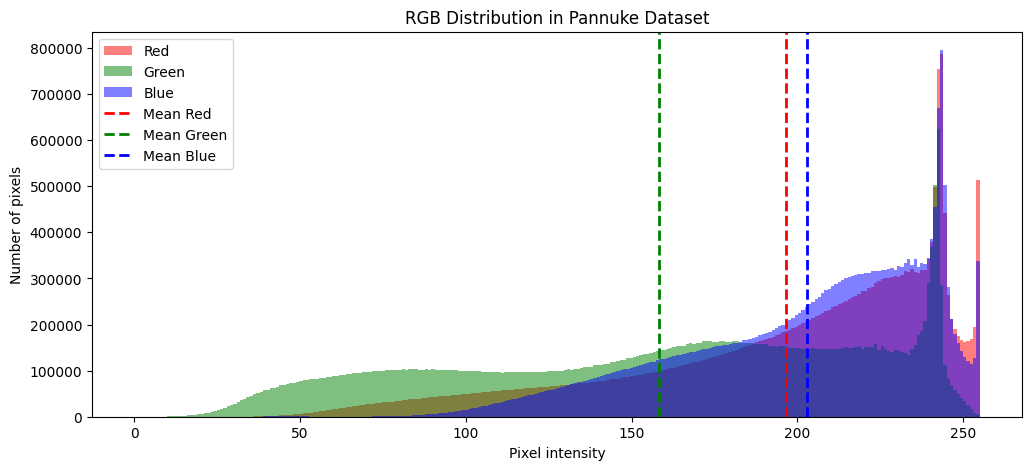

In [46]:
df = pd.DataFrame({
    'R': R_values,
    'G': G_values,
    'B': B_values
})

print(df.describe())

plt.figure(figsize=(12,5))

plt.hist(R_values, bins=256, color='red', alpha=0.5, label='Red')
plt.hist(G_values, bins=256, color='green', alpha=0.5, label='Green')
plt.hist(B_values, bins=256, color='blue', alpha=0.5, label='Blue')

plt.axvline(R_mean, color='red', linestyle='dashed', linewidth=2, label='Mean Red')
plt.axvline(G_mean, color='green', linestyle='dashed', linewidth=2, label='Mean Green')
plt.axvline(B_mean, color='blue', linestyle='dashed', linewidth=2, label='Mean Blue')


plt.title("RGB Distribution in Pannuke Dataset")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.legend()
plt.savefig("hist_RGB_distribuition_Nuinsseg.png", dpi=300)
plt.show()

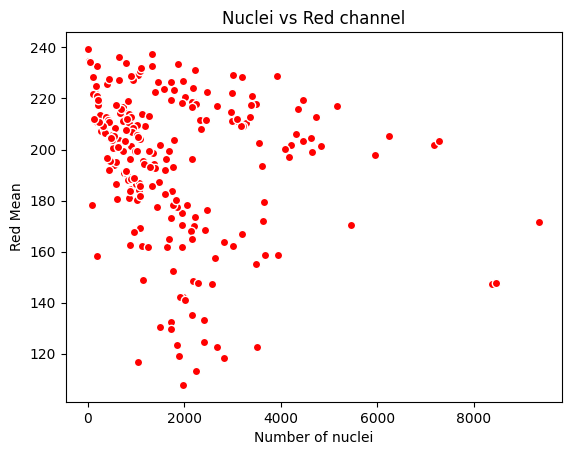

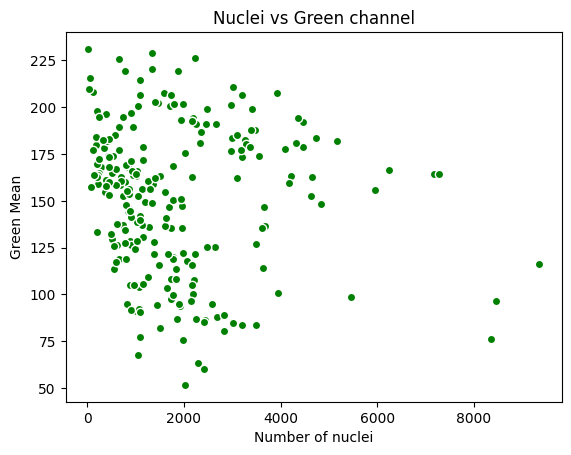

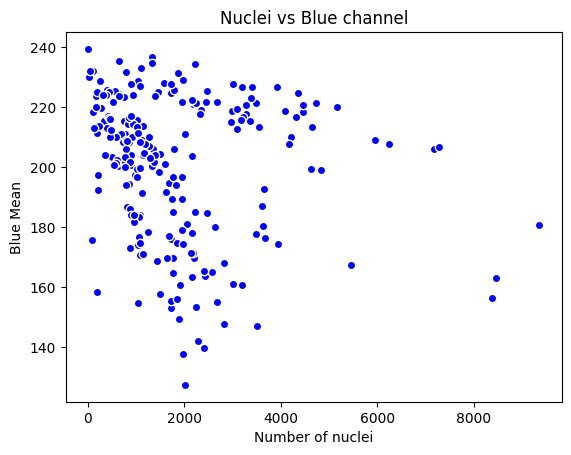

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_images["nuclei"], df_images["R_mean"], edgecolor='white', color= 'red')
plt.xlabel("Number of nuclei")
plt.ylabel("Red Mean")
plt.title("Nuclei vs Red channel")
plt.savefig("scatter_nuclei_VS_red_Nuinsseg.png", dpi=300)

plt.show()

plt.figure()
plt.scatter(df_images["nuclei"], df_images["G_mean"], edgecolor='white', color= 'green')
plt.xlabel("Number of nuclei")
plt.ylabel("Green Mean")
plt.title("Nuclei vs Green channel")
plt.savefig("scatter_nuclei_VS_green_Nuinsseg.png", dpi=300)
plt.show()

plt.figure()
plt.scatter(df_images["nuclei"], df_images["B_mean"], edgecolor='white', color= 'blue')
plt.xlabel("Number of nuclei")
plt.ylabel("Blue Mean")
plt.title("Nuclei vs Blue channel")
plt.savefig("scatter_nuclei_VS_blue_Nuinsseg.png", dpi=300)
plt.show()

In [48]:
df_images.to_csv("df_images_Lizard.csv", index=False)
df_nuclei.to_csv("df_nuclei_Lizard.csv", index=False)
df_dataset.to_csv("df_dataset_Lizard.csv", index=False)